In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer, LabelEncoder
#from sklearn import metrics 
from xailib.data_loaders.dataframe_loader import prepare_dataframe

 
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
 
from sklearn.compose import make_column_selector as selector

from lore_sa.dataset import TabularDataset
from lore_sa.surrogate import DecisionTreeSurrogate

import matplotlib.pyplot as plt


In [32]:
df = pd.read_csv("../../datasets/Final_data.csv")
 
df = df.loc[:,['Class_label','Week5_Covid', 'Week4_Covid', 'Week3_Covid', 'Week5_Mobility','Week4_Mobility','Week3_Mobility','Week2_Mobility', 'Days_passed', 'Duration']]
 
mask = df.drop(["Class_label"], axis=1).isna().all(axis=1) & df['Class_label'].notna()
result_df = df[~mask]
#df = df.dropna(how = 'all')
result_df = result_df.fillna("NONE")


In [33]:
result_df.head()

,Class_label,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
0,c1,c4,c4,c3,m1,m1,m1,m1,63.0,84
1,c2,c4,c4,c4,m4,m1,m1,m1,56.0,7
2,c2,c1,c1,c1,m3,m3,m3,m3,147.0,14
3,c3,c2,c3,c4,m4,m4,m4,m1,42.0,14
4,c3,c1,c1,c1,m3,m3,m3,m3,161.0,14


In [34]:
y = result_df["Class_label"].values
X_feat = result_df.loc[:,'Week5_Covid':'Duration']

In [35]:
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

In [36]:
numerical_columns = numerical_columns_selector(X_feat)
categorical_columns = categorical_columns_selector(X_feat)

In [37]:
covid_categories = ['NONE', 'c1', 'c2', 'c3', 'c4']
mobility_categories = ['NONE','m1', 'm2', 'm3', 'm4']
 
enc = OrdinalEncoder(categories=[covid_categories,covid_categories,covid_categories, mobility_categories,mobility_categories,mobility_categories,mobility_categories])
numerical_preprocessor = StandardScaler()

In [38]:
preprocessor = ColumnTransformer(
    [
        ("ordinal-encoder", enc, categorical_columns),
        ("standard_scaler", numerical_preprocessor, numerical_columns),
    ]
)

In [39]:
clf = RandomForestClassifier(n_estimators = 100, random_state=0)
model = make_pipeline(preprocessor, clf)
 
#y_prediction = cross_val_predict(model, X_feat,y, cv=5)
#acc = cross_val_score(model, X_feat,y, cv=5)

In [40]:
data_train, data_test, target_train, target_test = train_test_split(
    X_feat, y, random_state=0
)

In [41]:
model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('ordinal-encoder',
                                                  OrdinalEncoder(categories=[['NONE',
                                                                              'c1',
                                                                              'c2',
                                                                              'c3',
                                                                              'c4'],
                                                                             ['NONE',
                                                                              'c1',
                                                                              'c2',
                                                                              'c3',
                                                                              'c4'],
                                                                             ['NONE',
                                                                              'c1',
                                                                              'c2',
                                                                              'c3',
                                                                              'c4'],
                                                                             ['NONE',
                                                                              'm1',
                                                                              'm2',
                                                                              'm3',
                                                                              'm4'],
                                                                             ['NONE',
                                                                              'm1',
                                                                              'm2',
                                                                              'm3',
                                                                              'm4'],
                                                                             ['NONE',
                                                                              'm1',
                                                                              'm2',
                                                                              'm3',
                                                                              'm4'],
                                                                             ['NONE',
                                                                              'm1',
                                                                              'm2',
                                                                              'm3',
                                                                              'm4']]),
                                                  ['Week5_Covid', 'Week4_Covid',
                                                   'Week3_Covid',
                                                   'Week5_Mobility',
                                                   'Week4_Mobility',
                                                   'Week3_Mobility',
                                                   'Week2_Mobility']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['Days_passed',
                                                   'Duration'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=0))])

In [42]:
data_train

,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
255,c1,c1,c2,m4,m4,m4,m1,42.0,7
229,c3,c3,c3,m3,m2,m3,m3,322.0,35
300,c3,c3,c3,m2,m3,m2,m2,329.0,21
7,c3,c4,c4,m2,m3,m3,m3,357.0,49
160,c1,c1,c2,m4,m4,m4,m1,42.0,21
...,...,...,...,...,...,...,...,...,...
323,c3,c3,c3,m3,m3,m3,m4,224.0,63
192,c1,c1,c1,m4,m4,m4,m4,182.0,42
117,c3,c4,c4,m3,m4,m4,m4,273.0,28
47,c3,c4,c4,m3,m4,m4,m3,273.0,21


In [43]:
_ = model.fit(data_train, target_train)
 
y_predict = model.predict(data_test)
 
print(model.score(data_test, target_test))

0.8888888888888888


2024-06-04 14:14:48,169 matplotlib.colorbar DEBUG    locator: <matplotlib.ticker.AutoLocator object at 0x7fd15656d1c0>


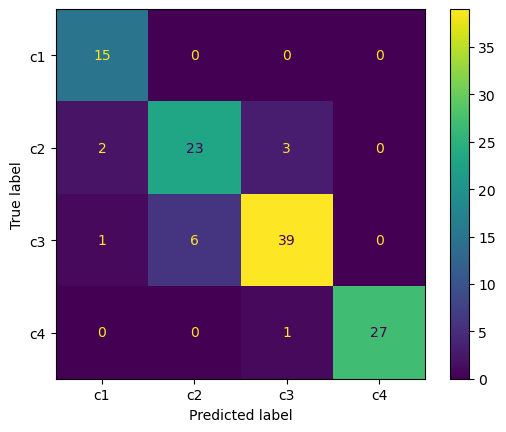

In [44]:
predictions = model.predict(data_test)
cm = confusion_matrix(target_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()


In [45]:
model.predict(data_train[10:11])

array(['c3'], dtype=object)

In [46]:
preprocessor.transform(data_train[10:11])

array([[ 3.        ,  4.        ,  4.        ,  3.        ,  3.        ,
         3.        ,  3.        ,  0.33443979, -0.42957844]])

# RANDOM Neighborhood generation

In [47]:
dataset = TabularDataset.from_csv('../../datasets/Final_data.csv', class_name = "Class_label")
dataset.df

2024-06-04 14:14:59,458 root         INFO     ../../datasets/Final_data.csv file imported


,Unnamed: 0,id,Name,Sequence ID,Province name,Start time,End time,Duration,Temporal context start,Temporal context end,...,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Week1_Mobility,Week5_Covid_encoded,Week3_Covid_encoded,Covid_trend,Days_passed,Class_label
0,1,01_c1_12_20/04/2020_12/07/2020,NaN,1,Araba/ lava,20/04/2020,12/7/2020,84,9/3/2020,20/04/2020,...,m1,m1,m1,m1,m1,4,3,D,63.0,c1
1,3,01_c2_1_13/04/2020..19/04/2020,NaN,1,Araba/ lava,13/04/2020,19/04/2020,7,2/3/2020,13/04/2020,...,m4,m1,m1,m1,m1,4,4,S,56.0,c2
2,4,01_c2_2_13/07/2020_26/07/2020,NaN,1,Araba/ lava,13/07/2020,26/07/2020,14,1/6/2020,13/07/2020,...,m3,m3,m3,m3,m3,1,1,S,147.0,c2
3,6,01_c3_2_30/03/2020_12/04/2020,NaN,1,Araba/ lava,30/03/2020,12/4/2020,14,17/02/2020,30/03/2020,...,m4,m4,m4,m1,m1,2,4,I,42.0,c3
4,7,01_c3_2_27/07/2020_09/08/2020,NaN,1,Araba/ lava,27/07/2020,9/8/2020,14,15/06/2020,27/07/2020,...,m3,m3,m3,m3,m3,1,1,S,161.0,c3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,617,50_c3_7_16/11/2020_03/01/2021,NaN,50,Zaragoza,16/11/2020,3/1/2021,49,5/10/2020,16/11/2020,...,m3,m3,m3,m3,m3,4,4,S,273.0,c3
464,618,50_c3_13_08/02/2021_09/05/2021,NaN,50,Zaragoza,8/2/2021,9/5/2021,91,28/12/2020,8/2/2021,...,m2,m3,m3,m3,m3,4,4,S,357.0,c3
465,619,50_c4_5_20/07/2020_23/08/2020,NaN,50,Zaragoza,20/07/2020,23/08/2020,35,8/6/2020,20/07/2020,...,m3,m3,m3,m3,m2,1,1,S,154.0,c4
466,620,50_c4_6_05/10/2020_15/11/2020,NaN,50,Zaragoza,5/10/2020,15/11/2020,42,24/08/2020,5/10/2020,...,m3,m3,m3,m3,m3,3,3,S,231.0,c4


In [48]:
dataset.df = dataset.df.loc[:,['Class_label','Week5_Covid', 'Week4_Covid', 'Week3_Covid', 'Week5_Mobility','Week4_Mobility','Week3_Mobility','Week2_Mobility', 'Days_passed', 'Duration']]
mask = dataset.df.drop(["Class_label"], axis=1).isna().all(axis=1) & dataset.df['Class_label'].notna()
dataset.df = dataset.df[~mask]
#df = df.dropna(how = 'all')
dataset.df  = dataset.df .fillna("NONE")

In [49]:
dataset.df

,Class_label,Week5_Covid,Week4_Covid,Week3_Covid,Week5_Mobility,Week4_Mobility,Week3_Mobility,Week2_Mobility,Days_passed,Duration
0,c1,c4,c4,c3,m1,m1,m1,m1,63.0,84
1,c2,c4,c4,c4,m4,m1,m1,m1,56.0,7
2,c2,c1,c1,c1,m3,m3,m3,m3,147.0,14
3,c3,c2,c3,c4,m4,m4,m4,m1,42.0,14
4,c3,c1,c1,c1,m3,m3,m3,m3,161.0,14
...,...,...,...,...,...,...,...,...,...,...
463,c3,c4,c4,c4,m3,m3,m3,m3,273.0,49
464,c3,c4,c4,c4,m2,m3,m3,m3,357.0,91
465,c4,c1,c1,c1,m3,m3,m3,m3,154.0,35
466,c4,c3,c3,c3,m3,m3,m3,m3,231.0,42


## ONE HOT ECONDING

In [50]:
#need to update the dropped columns
dataset.update_descriptor()

In [51]:
dataset.descriptor

{'numeric': {'Days_passed': {'index': 8,
   'min': 42.0,
   'max': 441.0,
   'mean': 234.3803418803419,
   'std': 119.79261432930082,
   'median': 231.0,
   'q1': 147.0,
   'q3': 350.0},
  'Duration': {'index': 9,
   'min': 7,
   'max': 147,
   'mean': 40.01068376068376,
   'std': 27.219425083695846,
   'median': 35.0,
   'q1': 21.0,
   'q3': 49.0}},
 'categorical': {'Week5_Covid': {'index': 1,
   'distinct_values': ['c4', 'c1', 'c2', 'c3'],
   'count': {'c4': 123, 'c1': 118, 'c2': 59, 'c3': 168}},
  'Week4_Covid': {'index': 2,
   'distinct_values': ['c4', 'c1', 'c3', 'c2'],
   'count': {'c4': 133, 'c1': 100, 'c3': 166, 'c2': 69}},
  'Week3_Covid': {'index': 3,
   'distinct_values': ['c3', 'c4', 'c1', 'c2'],
   'count': {'c3': 173, 'c4': 127, 'c1': 81, 'c2': 87}},
  'Week5_Mobility': {'index': 4,
   'distinct_values': ['m1', 'm4', 'm3', 'm2'],
   'count': {'m1': 54, 'm4': 115, 'm3': 215, 'm2': 84}},
  'Week4_Mobility': {'index': 5,
   'distinct_values': ['m1', 'm3', 'm4', 'm2'],
   'co

In [52]:
from lore_sa.encoder_decoder import TabularEnc
encoder = TabularEnc(dataset.descriptor)

encoded = []
for x in dataset.df.iloc:
    encoded.append(encoder.encode(x.values))

### Generator

In [53]:
encoded_df = pd.DataFrame(encoded, columns = [encoder.encoded_features[i] for i in range(len(encoded[0]))])
encoded_df

,Class_label,Week5_Covid=c4,Week5_Covid=c1,Week5_Covid=c2,Week5_Covid=c3,Week4_Covid=c4,Week4_Covid=c1,Week4_Covid=c3,Week4_Covid=c2,Week3_Covid=c3,...,Week3_Mobility=m1,Week3_Mobility=m3,Week3_Mobility=m4,Week3_Mobility=m2,Week2_Mobility=m1,Week2_Mobility=m3,Week2_Mobility=m2,Week2_Mobility=m4,Days_passed,Duration
0,0,1,0,0,0,1,0,0,0,1,...,1,0,0,0,1,0,0,0,63,84
1,1,1,0,0,0,1,0,0,0,0,...,1,0,0,0,1,0,0,0,56,7
2,1,0,1,0,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,147,14
3,2,0,0,1,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,42,14
4,2,0,1,0,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,161,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,2,1,0,0,0,1,0,0,0,0,...,0,1,0,0,0,1,0,0,273,49
464,2,1,0,0,0,1,0,0,0,0,...,0,1,0,0,0,1,0,0,357,91
465,3,0,1,0,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,154,35
466,3,0,0,0,1,0,0,1,0,1,...,0,1,0,0,0,1,0,0,231,42


In [26]:
x

Class_label          c4
Week5_Covid          c3
Week4_Covid          c3
Week3_Covid          c3
Week5_Mobility       m3
Week4_Mobility       m2
Week3_Mobility       m3
Week2_Mobility       m2
Days_passed       322.0
Duration             35
Name: 467, dtype: object

In [55]:
dataset.class_name

'Class_label'

In [74]:
encoder = TabularEnc(dataset.descriptor)

In [75]:
features = [c for c in encoded_df.columns if c != dataset.class_name]

x = encoded_df[features].iloc[10].values

from lore_sa.neighgen.random import RandomGenerator

gen = RandomGenerator()

neighbour = gen.generate(x, 100, dataset.descriptor, onehotencoder = encoder)

neighbour.df

ValueError: 'a' cannot be empty unless no samples are taken

In [77]:
x

array([  0,   0,   0,   1,   0,   0,   1,   0,   1,   0,   0,   0,   0,
         0,   1,   0,   0,   1,   0,   0,   0,   1,   0,   0,   0,   1,
         0,   0, 238,  42])

In [76]:
encoder.decode(encoded[0])

array(['c1', 'c4', 'c4', 'c3', 'm1', 'm1', 'm1', 'm1', '63', '84'],
      dtype='<U21')

In [ ]:
neighbour.df.to_csv('../../datasets/random_neigh.csv', index=False) 